In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.widgets as mwidgets
import matplotlib.path as mpath
import numpy as np
import matplotlib.path as mpath

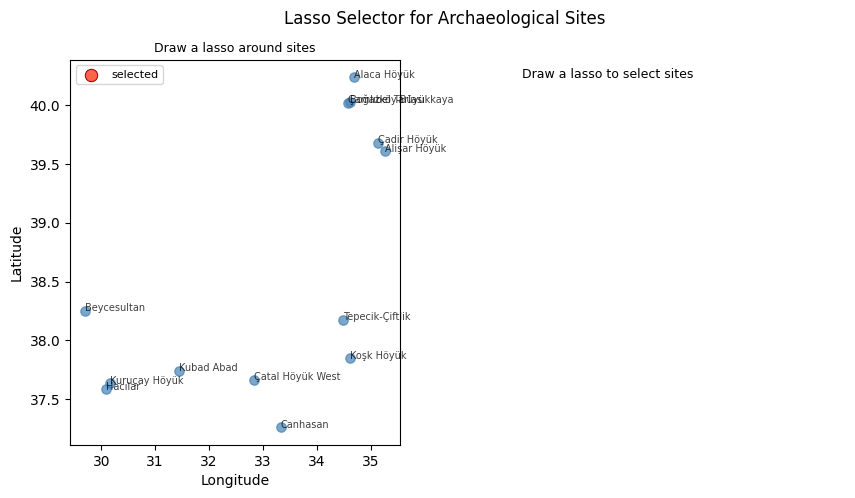

In [4]:
# Load data
file_path = "/Users/evijonas/python/archyviz/archyviz-site-geocoords.xlsx"
df = pd.read_excel(file_path)

# Keep only rows with coordinates
df = df.dropna(subset=["Latitude", "Longitude"]).copy()

# Coordinates
x = df["Longitude"].to_numpy()
y = df["Latitude"].to_numpy()
sites = df["Site"].to_numpy()
xy = np.c_[x, y]

# Plot layout
fig, (ax_map, ax_list) = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.35)
fig.suptitle("Lasso Selector for Archaeological Sites", fontsize=12)

# Site scatterplot
ax_map.scatter(x, y, c="steelblue", s=45, alpha=0.7, zorder=2)

selected_sc = ax_map.scatter(
    [], [], c="tomato", s=80, zorder=5,
    edgecolors="darkred", linewidths=0.7,
    label="selected"
)

for site, lon, lat in zip(sites, x, y):
    ax_map.text(lon, lat, site, fontsize=7, alpha=0.75)

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_title("Draw a lasso around sites", fontsize=9)
ax_map.legend(fontsize=8)

# Text panel for selected sites
ax_list.axis("off")
selected_text = ax_list.text(
    0.02, 0.98,
    "Draw a lasso to select sites",
    transform=ax_list.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

def on_lasso(verts):
    path = mpath.Path(verts)
    mask = path.contains_points(xy)
    indices = np.where(mask)[0]

    if len(indices) > 0:
        selected_sc.set_offsets(xy[indices])

        selected_sites = sites[indices]
        site_list = "\n".join(f"- {s}" for s in selected_sites)

        selected_text.set_text(
            f"{len(indices)} sites selected:\n\n{site_list}"
        )
    else:
        selected_sc.set_offsets(np.empty((0, 2)))
        selected_text.set_text("No sites selected")

    fig.canvas.draw_idle()

lasso = mwidgets.LassoSelector(ax_map, on_lasso, useblit=False)

plt.show()